In [5]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "iclr_close", "PPO_PLUS_FINAL"
runs_ppo_plus = api.runs(entity + "/" + project_99)
runs_ppo = api.runs(entity + "/" + project_995)

runs = itertools.chain(runs_ppo_plus,runs_ppo)



def filter_fn(run, alg_name,env_name, filter_dict):

    if run.config["algo_name"]==alg_name:
        for key, value in filter_dict.items():
            if key not in run.config or run.config[key] != value:
                return False
        return run.config["env_name"] == env_name and run.config["algo_name"] == "superppo"
    return False



dc = { 
        "superppo":{"gamma":0.99,"on_policy_data":False,"discount_actor":False,"momentum":0.9,"temperature":1.,"buffer_size":51200,"use_layer_norm":True,"clipping_ratio":0.25},
        "ppo":{"normalize_reward":True,"gamma":0.99}
}
      
      

legends = [""]
env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
max_steps = [1e6,1e6,1e6,1e6,1e6,5e6]
legend = [True,False,False,False,False,False]

for env_name,max_step,legend in zip(env_names,max_steps,legend):


    algo_name = dc.keys()
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
                
                
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                # if "plus" in algo:

                #     if filter_superppo(run,env_name,**dc[algo]):
                #         config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                #         # .name is the human-readable name of the run.
                #         name_list.append(run.name)
                #         full_df = run.history(samples=10000)
                #         tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                #         tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                #         tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                #         tmp_df = tmp_df[["step","average return"]]
                #         df = pd.concat([df, tmp_df], ignore_index=True)
                #         print(run.name)
                        

                # elif "ppo" in algo :        
                    
                #     if filter_ppo(run,env_name,**dc[algo]):
                #         config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                #         # .name is the human-readable name of the run.
                #         name_list.append(run.name)
                #         full_df = run.history(samples=10000)
                #         tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                #         tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                #         tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                #         tmp_df = tmp_df[["step","average return"]]
                #         df = pd.concat([df, tmp_df], ignore_index=True)
                #         print(run.name)

                if filter_fn(run,algo,env_name,dc[algo]):
                    
                    print(run.config)
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                    tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)



            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()

            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Policy Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            runs = itertools.chain(runs_ppo_plus,runs_ppo)

    if legend : plt.legend()      
    plt.savefig("./plots/benchmarks/"+env_name+"_benchmark.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

KeyError: 'alg_name'

In [4]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "iclr_995_tunisia_notemp", "iclr_995_tunisia_constant_temp"
runs_99 = api.runs(entity + "/" + project_99)
runs_995 = api.runs(entity + "/" + project_995)

runs = itertools.chain(runs_99,runs_995)
#runs = runs_995


def filter_superppo(run,env_name,gamma,discount_actor,on_policy_data,momentum,temperature):
    
    if not "temperature" in run.config : run.config["temperature"]=0.05
    return run.config["env_name"] == env_name and run.config["algo_name"] == "superppo" and gamma == run.config["gamma"] and discount_actor == run.config["discount_actor"] and temperature == run.config["temperature"] and on_policy_data == run.config["on_policy_data"] and momentum == run.config["momentum"]


dc = {"ppo-v2":{"gamma":0.995,"on_policy_data":False,"discount_actor":True,"momentum":0.9,"temperature":0.05},
      "ppo-v2(on_policy_buffer)":{"gamma":0.995,"on_policy_data":True,"discount_actor":True,"momentum":0.9,"temperature":0.05},
      "ppo-v2(no_discount)":{"gamma":0.995,"on_policy_data":False,"discount_actor":False,"momentum":0.9,"temperature":0.05},
      "ppo-v2(no_entropy)":{"gamma":0.995,"on_policy_data":False,"discount_actor":True,"momentum":0.9,"temperature":0.}}
legends = [""]
env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
max_steps = [1e6,1e6,1e6,1e6,1e6,5e6]
legend = [True,False,False,False,False,False]

for env_name,max_step,legend in zip(env_names,max_steps,legend):


    algo_name = dc.keys()
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
                
                
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if "v2" in algo:

                    if filter_superppo(run,env_name,**dc[algo]):
                        config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                        # .name is the human-readable name of the run.
                        name_list.append(run.name)
                        full_df = run.history(samples=10000)
                        tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                        tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                        tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                        tmp_df = tmp_df[["step","average return"]]
                        df = pd.concat([df, tmp_df], ignore_index=True)
                        print(run.name)
                        

          


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()

            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Policy Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            runs = itertools.chain(runs_99,runs_995)

    if legend : plt.legend()      
    plt.savefig("./plots/ablations/"+env_name+"_ablation.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools
import matplotlib

sns.set(font_scale=3.)
#matplotlib.rcParams.update({'font.size': 28})
sns.set_theme()

matplotlib.rcParams.update({'font.size': 50})



os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "finishitto", "finishitto_995"

runs_995 = api.runs(entity + "/" + project_995)
#runs = itertools.chain(runs_99,runs_995,runs_onp)
runs = runs_995




env_name = "InvertedDoublePendulum-v5"

dc = {"TOP-PPO":{"gamma":0.995,"discount_actor":True,"momentum":0.,"on_policy_data":False},
      "-Discount PG":{"gamma":0.995,"discount_actor":False,"momentum":0.,"on_policy_data":False},
      "-Off policy":{"gamma":0.995,"discount_actor":True,"momentum":0.,"on_policy_data":True},
      "+Momentum":{"gamma":0.995,"discount_actor":True,"momentum":0.9,"on_policy_data":False},
      }
legends = [""]


env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
max_steps = [1e6,1e6,1e6,1e6,1e6,5e6]
legend = [True,False,False,False,False,False]

for env_name,max_step,legend in zip(env_names,max_steps,legend):


    
    algo_name = ["TOP-PPO","-Discount PG","-Off policy","+Momentum"]
    
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if filter_superppo(run,env_name,**dc[algo]):
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/episode.return','_step']].dropna(axis=0)
                    tmp_df["average return"] = tmp_df['evaluation/episode.return'].rolling(window=10).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)

            


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()
            
            #plt.axis('equal')
            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Average Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            #runs = itertools.chain(runs_99,runs_995)
            runs = itertools.chain(runs_99,runs_995)

    if legend : plt.legend()      
    plt.savefig("./plots/ablations_995/"+env_name+"_ablation_995.pdf", format="pdf", bbox_inches="tight")  
    plt.show()


lemon-valley-401
rosy-sun-40
prime-serenity-39
solar-vortex-38
stellar-moon-36
wobbly-elevator-34
eager-glade-35
ethereal-sea-36
crimson-bee-33
crimson-sky-30
polished-forest-31
winter-morning-18
northern-resonance-11
rose-spaceship-8
misty-planet-6
light-tree-6
lemon-valley-401
rosy-sun-40
prime-serenity-39
solar-vortex-38
stellar-moon-36
wobbly-elevator-34
eager-glade-35
ethereal-sea-36
crimson-bee-33
crimson-sky-30
polished-forest-31
twilight-sun-98
iconic-sunset-100
divine-silence-99
olive-elevator-96
curious-fog-95
bumbling-oath-5
stilted-surf-4
tough-snowball-3
amber-terrain-1
genial-music-2
lyric-valley-85
likely-pond-84
tough-salad-82
twilight-snowball-82
light-armadillo-81


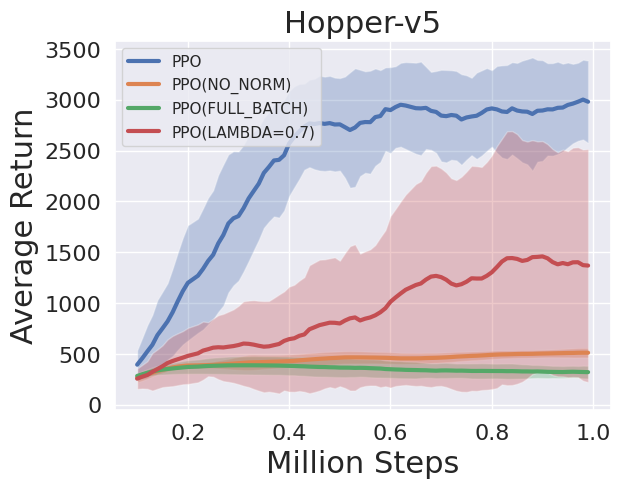

classic-morning-9
glorious-totem-10
brisk-dew-8
charmed-dawn-7
fresh-bee-5
gentle-lion-6
crisp-galaxy-1
polar-pond-4
faithful-thunder-1
glowing-puddle-1
stilted-music-40
giddy-cloud-38
olive-river-39
bumbling-universe-36
azure-hill-36
fancy-thunder-104
eager-snow-103
worldly-plasma-101
confused-resonance-102
hopeful-rain-97
honest-night-26
silver-disco-23
dashing-frost-21
worthy-cosmos-22
stoic-waterfall-23
sleek-moon-80
azure-dawn-76
fluent-yogurt-76
scarlet-disco-76
apricot-plasma-77


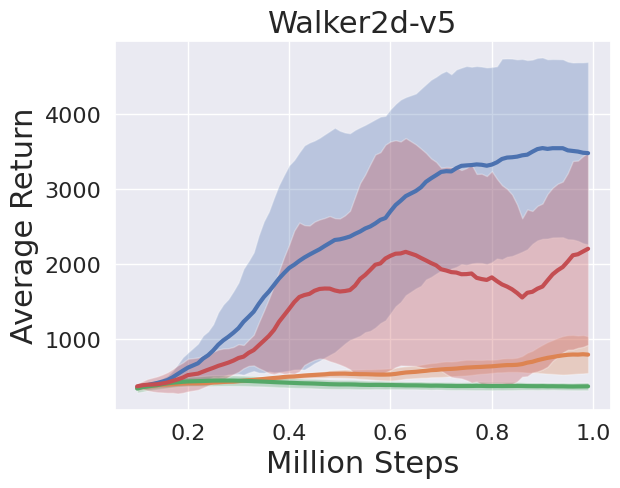

In [3]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools
import matplotlib

sns.set(font_scale=3.)
#matplotlib.rcParams.update({'font.size': 28})
sns.set_theme()

matplotlib.rcParams.update({'font.size': 50})



os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "iclr_close", "iclr_ppo_diagnosis"

runs_995 = api.runs(entity + "/" + project_995)
runs_99 = api.runs(entity + "/" + project_99)
runs = itertools.chain(runs_99,runs_995,runs_99)





env_name = "InvertedDoublePendulum-v5"

dc = {"PPO":{"normalize_reward":True,"full_batch":False,"gae_lambda":0.95},
      "PPO(no_norm)":{"normalize_reward":False,"full_batch":False,"gae_lambda":0.95},
      "PPO(full_batch)":{"normalize_reward":True,"full_batch":True,"gae_lambda":0.95},
      "PPO(lambda=0.7)":{"normalize_reward":True,"full_batch":False,"gae_lambda":0.7},
      }
legends = [""]


env_names = ["Hopper-v5","Walker2d-v5"]
max_steps = [1e6,1e6]
legend = [True,False]


def filter_ppo(run,env_name,normalize_reward,gae_lambda,full_batch):
    
    
    if not "gae_lambda" in run.config : run.config["gae_lambda"]=0.95
    if not "full_batch" in run.config : run.config["full_batch"]=False
    return run.config["env_name"] == env_name and gae_lambda == run.config["gae_lambda"] and run.config["algo_name"] == "ppo" and normalize_reward == run.config["normalize_reward"] and full_batch == run.config["full_batch"]


for env_name,max_step,legend in zip(env_names,max_steps,legend):


    
    algo_name = dc.keys()
    
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if filter_ppo(run,env_name,**dc[algo]):
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                    tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)

            


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()
            
            #plt.axis('equal')
            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Average Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            #runs = itertools.chain(runs_99,runs_995)
            runs = itertools.chain(runs_99,runs_995)

    if legend : plt.legend()      
    plt.savefig("./plots/diagnostics/"+env_name+"diagnostic.pdf", format="pdf", bbox_inches="tight")  
    plt.show()